In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
print(torch.__version__)


torch.manual_seed(42)

2.9.1+cpu


In [3]:
# Import custom modules
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from src.dnn_utils import *
from src.plots_utils import *

# Introduction

This notebook presents the implementation of a fully connected neural network from scratch, using PyTorch tensors and index operations, without relying on PyTorch's neural network modules.
<br><br>


The forward and backward propagation equations are first derived explicitly using index notation and Einstein summation, and then implemented using PyTorch. A small toy model is used throughout the notebook to verify the derivations and validate each computational step.

The strategy is as follows:

$$
\boxed{
\begin{array}{c}
\mathbf{1.\ Derivation} \\[6pt]
\text{Forward \& Backward Propagation} \\[6pt]
\small\text{Equations with index notation}
\end{array}
}
\quad\longrightarrow\quad
\boxed{
\begin{array}{c}
\mathbf{2.\ Implementation} \\[6pt]
\small\text{Using PyTorch Tensors}
\end{array}
}
\hspace{0.5cm}
\quad\longrightarrow\quad
\boxed{
\begin{array}{c}
\mathbf{3.\ Training} \\[6pt]
\small\text{On Toy model}
\end{array}
}
\hspace{0.5cm}
\quad\longrightarrow\quad
\boxed{
\begin{array}{c}
\mathbf{4.\ Validation} \\[6pt]
\small\text{Gradien Checking}
\end{array}
}
$$

Throughout the notebook, we will use tensor notation and tensor operations in the computational sense, without introducing the formal mathematical definition of tensors.


### Defining the variables

The first step in constructing a neural network is to know the dimensions or shapes of the variables that enter into the construction.  Most of these variables are matrices, like the input data and the weights, but there are also column vectors such as the biases, which can be represented as matrices with one column.

For a neural network with $L+1$ layers, the layers are indexed by   $[l]$,  where the  index $l = 0, \ldots, L$ denotes the $l$-th layer. For instance, the input layer is labeled by $[0]$, the  first hidden layer by $[1]$,  the output layer by $[L]$. The square brackets are used to differentiate layer indices from other indices. The number of nodes in each layer is denoted by $n^{[l]}$.

General architectures, such as CNNs, require higher-dimensional tensors as variables but for a fully connected neural network, the main variables are represented as matrices. Here is the notation for our variables: 

* $X$:&nbsp; input  of shape $(n^{\scriptsize[0]},m)$ with $n^{\scriptsize[0]}$ features and $m$ samples.

* $Y$: &nbsp; actual output  of shape $(1, m)$.

* $W^{\scriptsize[l]}$: &nbsp; weights  in the $l$-th layer with shape $(n^{\scriptsize[l]}, n^{\scriptsize[l-1]})$.

* $b^{\scriptsize[l]}$: &nbsp; biases in the $l$-th layer with shape $(n^{\scriptsize[l]},1)$.


* $Z^{\scriptsize[l]}$: &nbsp; linear transformation in the $l$-th layer with shape $(n^{\scriptsize[l]}, m)$

* $A^{\scriptsize[l]}$: &nbsp; activation  in the $l$-th layer with shape $(n^{\scriptsize[l]}, m)$.

Note that
* The dimension of $W^{\scriptsize[l]}$ and $b^{\scriptsize[l]}$ do not depend of the number of samples $m$.

* $Z^{\scriptsize[l]}$ and $A^{\scriptsize[l]}$ have the same shape and it depends on $m$.



<br>

## Defining the toy model

The toy neural network  considered, consist of:

* One input layer with 3 nodes and with  $m = 3$ samples.

* A hidden layer  with 4 nodes and ReLU activation.

* A second hidden layer with 2 nodes and ReLU activation.

* An output layer with 1 node and Sigmoid activation.


Such model is represesnted as $[ n^{\scriptsize[0]} \, ,
n^{\scriptsize[1]} \, ,
n^{\scriptsize[2]} \, ,
n^{\scriptsize[3]} ] = [3,4,2,1]$



































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































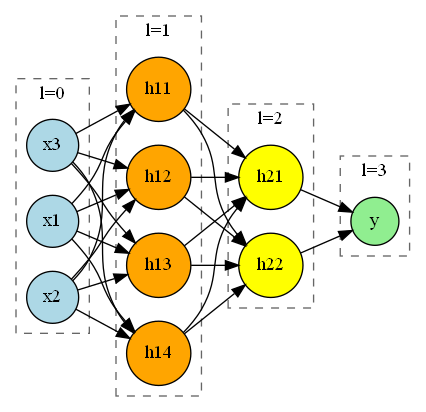

In [4]:
dot = build_nn_diagram()
gv_to_markdown(dot, caption="Simple NN with $L=3$")

For this model, the input and ouput matrices are of the form:
$$
X : (3,3)  , \quad \quad \, \, Y: (1,3) \\
$$
The weights and biases that associated with each layer in the network have the shape:
$$
\begin{align}
& \\
W^{[1]} &: (4,3) , \quad \quad   b^{[1]}: (4,1)\\
W^{[2]} &: (2,4) ,  \quad \quad   b^{[2]}: (2,1)\\
W^{[3]} &: (1,2),  \quad \quad   b^{[3]}: (1,1)\\\\
\end{align}
$$


We will also have matrices defined at each layer: the linear transformations and the activations:
$$
\begin{align}
Z^{[1]} &: (4,3) , \quad \quad   A^{[1]}: (4,3)\\
Z^{[2]} &: (2,3) ,  \quad \quad   A^{[2]}: (2,3)\\
Z^{[3]} &: (1,3),  \quad \quad   A^{[3]}: (1,3)\\\\
\end{align}
$$


We can now translate these definitions into PyTorch, where these quantities are represented as objects of type torch.Tensor.


<br><br>
**A note: In the folllowing, we define the functions for forward propagation, cost computation, backpropagation, and parameter updates. Each function is implemented independently and then tested using the toy model defined above.**

In [5]:
def initialize_parameters(layers):
  """
    Initialize the weights and biases of the neural network.

    Parameters
    ----------
    layers : list
        Number of neurons in each layer of the network.

    Returns
    -------
    weights : dict
        Dictionary containing the weight matrix W[l] for each layer.
        Each W[l] has shape (layers[l], layers[l-1]).

    biases : dict
        Dictionary containing the bias vector b[l] for each layer.
        Each b[l] has shape (layers[l], 1).
    """
  torch.manual_seed(42)

  weights = {}
  biases = {}

  L = len(layers)   # number of layers in the network

  for l in range(1, L):
    weights[l] = torch.randn(layers[l], layers[l-1])
    biases[l] = torch.randn(layers[l], 1)


  return weights, biases


Next we define the input and target tensors, together with the initial weights and biases, for the toy model. These quantities will be used throughout the implementation and testing of the network.

In [6]:
# Define the input  tensor X and the output tensor Y for the model
X = torch.rand(3,3)
Y = torch.tensor([[1., 0., 1.]])

print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")



# parameters for the model
weights_test, biases_test = initialize_parameters([3,4,2,1])
for l in range(1, len(weights_test)+1):
    print(f"\nLayer {l}:")
    print(f"W[{l}] shape: {weights_test[l].shape}")
    print(f"b[{l}] shape: {biases_test[l].shape}")


X shape: torch.Size([3, 3])
Y shape: torch.Size([1, 3])

Layer 1:
W[1] shape: torch.Size([4, 3])
b[1] shape: torch.Size([4, 1])

Layer 2:
W[2] shape: torch.Size([2, 4])
b[2] shape: torch.Size([2, 1])

Layer 3:
W[3] shape: torch.Size([1, 2])
b[3] shape: torch.Size([1, 1])


In addition to their shapes, tensors also have a data type (dtype), which determines how their numerical values are represented and stored.

In [7]:
print(X.dtype)
print(Y.dtype)
print(weights_test[1].dtype)
print(biases_test[1].dtype)

torch.float32
torch.float32
torch.float32
torch.float32




## Index notation

In the following, we use index notation to represent the components of the variables introduced above. For a matrix, two indices are required: one for the row and one for the column.
<br>

The indices used throughout the derivation are defined as follows:

* $i, \, j, k = 1, \ldots, n^{\scriptsize[l]}$,  these indices run over the number of nodes in layer $l$,
* $i^\prime, \,j^\prime,k^\prime = 1, \ldots, n^{\scriptsize[l-1]}$,  these indices range over the nodes in the previous layer  $l-1$.
* $ a, \, c, e = 1, \ldots, m$, these indices run over the number of samples.
<br>

Component notation for the variables in the $l$-th layer:
* $W^{\scriptsize[l]} \, \,\, \rightarrow \, W^{\scriptsize[l]}_{i j^\prime}$

* $b^{\scriptsize[l]}\,\,\,\,\,\,  \rightarrow \, b^{\scriptsize[l]}_{i1} $
* $Z^{\scriptsize[l]} \,\,\,\, \rightarrow Z^{\scriptsize[l]}_{i a}$
* $A^{\scriptsize[l]} \,\,\,\, \rightarrow A^{\scriptsize[l]}_{i a}$
<br>

For the variables in the previous layer $l-1$:
* $A_{prev}\,\,\,  \rightarrow \, A^{\scriptsize[l-1]}_{i^\prime a}$

* $ X \equiv A^{\scriptsize[0]} $





Note that  $W^{\scriptsize[l]}$ and $b^{\scriptsize[l]}$ do not carry the sample index $a$, since their values are shared across all samples.



<br>

## Linear transformation and Broadcasting
The linear transformation $Z = W X + b$ cannot be directly carried out using standard matrix addition rules because  $b$  and $WX$ have different shapes. In numerical computation, this operation is handled using *broadcasting*, which implicitly expands $b$ to match the shape of $WX$.

Nevertheless, index notation provides a way to represent the broadcasting operation as the product of matrix $b$ with shape $(n^{[l]}, 1)$ with a matrix of ones ${\bf 1}$  (with all of its componentes equal to 1) of size $(1,m)$. This product results in the the matrix $\tilde{b}$ with components $\tilde{b}_{i a}$. Thus, in index notation, the linear transformation becomes:
<br><br>
$$
Z^{\scriptsize[l]}_{i a} = W^{\scriptsize[l]}_{i j^\prime} A^{\scriptsize[l]}_{j^\prime a} + \tilde{b}^{\scriptsize[l]}_{i a}
$$

with  $\tilde{b}_{i a} = b_{i1}{\bf 1}_{1 a}$.
<br><br>
Applying the Einstein summation convention, the repeated index $j^\prime$
is implicitly summed over, leaving the free indices $i$ and $a$. Thus, both sides of the equation have the same shape $(n^{\scriptsize[l]}, m)$.


In these notes, we use $\tilde{b}_{i a}$  instead of the direct broadcasting and  "torch.einsum" as a direct implementation of the Einstein summation.

### Activation functions
The activation functions $\sigma(z)$ considered for the toy model are:
$$
\sigma(z) = \frac{1}{1 + e^{-z}}  \,\,\,\quad\quad  \mbox{Sigmoid function}
$$
<br>
and
$$
\sigma(z) = \mbox{max}(0,z) \,\,\,\quad\quad  \mbox{ReLU function}
$$
<br>
both functions are applied element wise to the elements of $Z$, not to the complete matrix $Z$. Therefore, we can write the selecte activation function  for each layer as:
<br><br>
$$
A_{i a} = \sigma(Z_{i a})
$$

#  Forward Propagation
The following implementation translates the tensor operations defined above into a forward propagation routine using PyTorch.

In [8]:
def forward_propagation(initial_input, weights, biases):
    """
    Perform forward propagation through the neural network.

    Parameters
    ----------
    initial_input : torch.Tensor
        Input data to the network. Has shape (n_x, m), where n_x
        is the number of input features and m is the number of samples.
    weights : dict
        Dictionary containing the weight matrix W[l] for each layer.
    biases : dict
        Dictionary containing the bias vector b[l] for each layer.

    Returns
    -------
    AL : torch.Tensor
        Output activation of the final layer.
    records : list
        List containing the cached values required for the backward pass.
        Each record contains (A_prev, W, b) and Z for one layer.
    """

    records = []
    A = [initial_input]
    L = len(weights)

    for l in range(1, L + 1):

        # Calculate linear transformation
        W = weights[l]
        b = biases[l]
        Z = torch.einsum('ij,ja->ia', W, A[l-1]) + b

        # Apply activation function
        if l < L:
            A_l = torch.relu(Z)
        else:
            A_l = torch.sigmoid(Z)

        A.append(A_l)

        # Store cache for backward pass
        triplet = (A[l-1], W, b)
        record = (triplet, Z)
        records.append(record)

    # Output of the last layer
    AL = A[-1]

    return AL, records

In [9]:
# Applying the functions to the toy model
AL_test, caches_test = forward_propagation(X, weights_test, biases_test)

L = len(weights_test)
for l in range(1, L + 1): # Iterate through layers 1 to L
    print(f"\nLayer {l}:")

    # For layer l, A_prev is the input activation to this layer.
    # It is stored as the first element of the triplet tuple in cache for layer l.
    A_prev_for_layer_l = caches_test[l-1][0][0]
    W_for_layer_l = caches_test[l-1][0][1]
    b_for_layer_l = caches_test[l-1][0][2]
    Z_for_layer_l = caches_test[l-1][1]


    print(f"A[{l-1}] shape:", A_prev_for_layer_l.shape)
    print(f"W[{l}] shape:", W_for_layer_l.shape)
    print(f"b[{l}] shape:", b_for_layer_l.shape)
    print(f"Z[{l}] shape:", Z_for_layer_l.shape)


print(f"\nFinal  A[{L}] shape:", AL_test.shape)


Layer 1:
A[0] shape: torch.Size([3, 3])
W[1] shape: torch.Size([4, 3])
b[1] shape: torch.Size([4, 1])
Z[1] shape: torch.Size([4, 3])

Layer 2:
A[1] shape: torch.Size([4, 3])
W[2] shape: torch.Size([2, 4])
b[2] shape: torch.Size([2, 1])
Z[2] shape: torch.Size([2, 3])

Layer 3:
A[2] shape: torch.Size([2, 3])
W[3] shape: torch.Size([1, 2])
b[3] shape: torch.Size([1, 1])
Z[3] shape: torch.Size([1, 3])

Final  A[3] shape: torch.Size([1, 3])


## Cost function

Following the Andrew Ng's notation, a loss function $\mathcal{L}$ measures error on a single training example, while a cost function $J$ is the average of the loss functions over the entire training set. Here, I use the cost function which in matrix notation has the form:
<br><br>
$$
J(\mathbf{W}, \mathbf{b})  = -\frac{1}{m}\Big( Y \cdot \mbox{log}(A^{L})^T  +  (1 - Y) \cdot \mbox{log}(1 - A^{L})^T \Big)
$$
<br>
with
$
\mathbf{W} = ({W}^{[1]}, \ldots,  {W}^{[L]})$ and $\mathbf{b} = ({b^{[1]}}, \ldots,  {b^{[L]}}).
$
<br><br>

In index notation,

$$
J(\mathbf{W}, \mathbf{b})
= - \frac{1}{m}
\left(
Y_{1,a}\,\log A^{[L]}_{1,a}
+
(1-Y_{1,a})
\log\left(1-A^{[L]}_{1,a}\right)
\right),
$$
<br><br>
Note that in this last equation, the term $Y_{1,a}\,\log A^{[L]}_{1,a}$ represents the element-wise product for each sample $a$. The repeated index $a$ indicates an implicit summation over the samples according to the Einstein summation. The same applies to the second term.

Here, we use torch.einsum to implement the summation directly.





In [10]:
def cost(AL, Y):
    """
    Compute the cost function for the network.

    Parameters
    ----------
    AL : torch.Tensor
        Predicted output of the network, with shape (1, m).
    Y : torch.Tensor
        Target output, with the same shape as AL.

    Returns
    -------
    cost : torch.Tensor
        Scalar value of the cost function.

    Notes
    -----
    The cost is computed using torch.einsum to implement the
    element-wise products and the summation over the samples
    according to the Einstein summation.
    """
    # Y has the same shape as AL (e.g., [1, m])
    m = Y.shape[1]

    # 'ia,ia->' contracts both indices i and a
    # according to the Einstein summation convention.
    log_probs = torch.einsum('ia,ia->', Y, torch.log(AL)) + \
                torch.einsum('ia,ia->', (1 - Y), torch.log(1 - AL))

    cost = (-1 / m) * log_probs

    return cost


In [11]:
# Applying function to the toy model
print("AL:", AL_test.dtype)

J = cost(AL_test, Y)

print("J:", J)
print("J dtype:", J.dtype)

AL: torch.float32
J: tensor(0.8060)
J dtype: torch.float32


In [12]:
AL, caches = forward_propagation(X, weights_test, biases_test)



# Gradient

We want to compute the gradients
  
$$
\frac{\partial {J}}{\partial {\mathbf W}}   = \Big( \frac{\partial {J}}{\partial W^{\small{[1]}}}, \ldots ,  \frac{\partial {J}}{\partial W^{\small{[L]}}}\Big)\,, \quad   \frac{\partial {J}}{\partial {\mathbf b}}   = \Big( \frac{\partial {J}}{\partial b^{\small{[1]}}}, \ldots ,  \frac{\partial {J}}{\partial b^{\small{[L]}}} \Big)
$$

<br>

*  Each block $\frac{\partial {J}}{\partial W^{\small{[l]}}}$  can be seen as a matrix of dimension $(n^{\small{[l]}}, n^{\small{[l-1]}})$.

<sos>

*  Similarly, each term $\frac{\partial {J}}{\partial b^{\scriptsize{[l]}}}$ represents a matrix of dimension $(n^{\scriptsize{[l]}}, 1)$   with  $l=1,…,L$.

With the index notation, it is possible to acces to each element $(i,j)$ of such matrices as:
$$
\frac{\partial {J}}{\partial W^{\scriptsize{[l]}}}  \rightarrow  \frac{\partial {J}}{\partial W^{\scriptsize{[l]}}_{i j^\prime}}
$$
Similarly,  

$$
\frac{\partial {J}}{\partial b^{\scriptsize{[l]}}}  \rightarrow  \frac{\partial {J}}{\partial b^{\scriptsize{[l]}}_{i }}
$$
<br>
Applying the chain-rule we have:

$$
\frac{\partial {J}}{\partial W_{i j^\prime}^{\scriptsize{[l]}}} =  \frac{\partial {J}}{\partial A_{k e} ^{\scriptsize{[l]}}} \,  \frac{\partial {A_{ke}^{\scriptsize{[l]}}}}{\partial Z_{j c}^{\scriptsize{[l]}}} \, \frac{\partial {Z_{j c}^{\scriptsize{[l]}}}}{\partial W_{i j^\prime}^{\scriptsize{[l]}}}
$$

We have to note that since $\sigma$ is an element-wise function, the derivative
of $A$ with respect to $Z$ is nonzero only when $k = j$ and $e = c$. Therefore we have:

$$
\begin{align}
\frac{\partial {J}}{\partial W_{i j^\prime}^{\scriptsize{[l]}}} & =  \underbrace{\Biggl(\frac{\partial {J}}{\partial A ^{\scriptsize{[l]}}} \,  \odot \frac{\partial {A^{\small{[l]}}}}{\partial Z^{\small{[l]}}} \Biggr)_{j c}}_{\text{Hadamard Product}} \, \frac{\partial {Z_{j c}^{\small{[l]}}}}{\partial W_{i j^\prime}^{\small{[l]}}}  \\
& \\
& = \Biggl(\frac{\partial {J}}{\partial A ^{\small{[l]}}} \, \odot \sigma^\prime\Biggr)_{j c} \, \delta_{ij}\delta_{j^\prime k^\prime} A^{[l-1]}_{k^\prime c}\\
&\\
& = \underbrace{\Bigl(\frac{\partial {J}}{\partial A^{\small{[l]}}} \odot \, \sigma^\prime \Bigr)_{i c} \,  A^{[l-1]}_{j^\prime c}}_{\text{Matrix Product (sum in $c$)}}
\end{align}
$$


<br><br>

Similarlly,

$$
\begin{align}
\frac{\partial {J}}{\partial b_{i 1}^{\scriptsize{[l]}}}  & =  \Biggl(\frac{\partial {J}}{\partial A ^{\scriptsize{[l]}}} \,  \odot  \frac{\partial {A^{\scriptsize{[l]}}}}{\partial Z^{\scriptsize{[l]}}} \Biggr)_{j c} \frac{\partial {Z_{j c}^{\scriptsize{[l]}}}}{\partial b_{i 1}^{\scriptsize[l]}} \\
& =   \Bigl(\frac{\partial {J}}{\partial A^{\scriptsize{[l]}}} \odot \, \sigma^\prime \Bigr)_{j c}\,\, \delta_{ij}{\bf{1}}_{1c}\\
& =  \underbrace{\Bigl(\frac{\partial {J}}{\partial A^{\scriptsize{[l]}}} \odot \, \sigma_{\scriptsize[l]}^\prime \Bigr)_{i c} \,{\bf{1}}_{1c}}_{\text{Matrix Product --(sum in $c$)}}
\end{align}
$$
<br><br>

In addition, we will need the gradient of $J$ with respect to $A_{\text{prev}}$.

$$
\begin{align}
\frac{\partial {J}}{\partial A_{i^\prime a}^{\scriptsize{[l-1]}}}  & =  \Biggl(\frac{\partial {J}}{\partial A ^{\scriptsize{[l]}}} \, \odot  \frac{\partial {A^{\scriptsize{[l]}}}}{\partial Z^{\scriptsize{[l]}}} \Biggr)_{j c} \,\,\frac{\partial {Z_{j c}^{\small{[l]}}}}{\partial A_{i^\prime a}^{[l-1 ]}} \\
& =   \Bigl(\frac{\partial {J}}{\partial A^{\scriptsize{[l]}}} \odot \, \sigma^\prime \Bigr)_{j c} \,\,\, \delta_{i^\prime j^\prime} \delta_{a c}\, W^{\small{[l]}}_{j  j^\prime}\\
& =  \underbrace{W^{\scriptsize{[l]}}_{j \, i^\prime} \, \Bigl(\frac{\partial {J}}{\partial A^{\scriptsize{[l]}}} \odot \, \sigma_{\scriptsize[l]}^\prime \Bigr)_{j a}}_{\text{Matrix Product --(sum in $j$)}}
\end{align}
$$

<br><br>
Note that after doing the contraction of the indices, the gradients of $J$ can be expressed as product of matrices

$$
\begin{align}
 \frac{\partial J}{\partial W^{\scriptsize[l]}} & =   \frac{\partial J}{\partial Z^{\scriptsize[l]}} \,(A^{\scriptsize[l-1]})^T  \\
 & \\
\frac{\partial {J}}{\partial b^{\scriptsize{[l]}}}  & =  \frac{\partial J}{\partial Z^{\scriptsize[l]}} {\bf{1}}^T\\
&\\
\frac{\partial {J}}{\partial A^{\scriptsize{[l-1]}}}  & =  (W^{\scriptsize{[l]}})^T \frac{\partial J}{\partial Z^{\scriptsize[l]}}
\end{align}
 $$

<br><br>
with

$$
\begin{align}
 \frac{\partial J}{\partial Z^{\scriptsize[l]}} & =
\frac{\partial J}{\partial A^{\scriptsize[l]}} \odot \sigma_{\scriptsize[l]}^\prime \\
&\\
\sigma_{\scriptsize[l]}^\prime = \frac{\partial A^{\scriptsize[l]}}{\partial Z^{\scriptsize[l]}}  &= \begin{cases}
1 & \mbox{for}\, Z^{\scriptsize[l]} > 0 \\
0  & \mbox{for} \, Z^{\scriptsize[l]} \leq 0
\end{cases}  \quad  \quad \mbox{for ReLu}\\
\\
\sigma_{\scriptsize[l]}^\prime = \frac{\partial A^{\scriptsize[l]}}{\partial Z^{\scriptsize[l]}}  &= A^{\scriptsize[l]} \odot (1 - A^{\scriptsize[l]})\quad  \quad  \quad
 \mbox{for Sigmoid}
\end{align}
$$



---


# Backpropagation

* Start with the last layer $l = L$. Since $J$ only depends on $A^{\scriptsize{[L]}}$, in matrix notation we have:

$$
\begin{align}
\frac{\partial {J}}{\partial A^{\small{[L]}}} & = - \frac{1}{m}\Bigg( \frac{Y}{A^{\small{[L]}}} -\
\frac{(1-Y)}{1 - A^{\small{[L]}}} \Bigg) \\
&\\
\sigma_{[L]}^\prime & = A^{[L]}\, \odot \, (1 - A^{[L]})
\end{align}
$$
where the Sigmoid activation was considered in this last layer.

Then,
$$
\frac{\partial {J}}{\partial Z^{\small{[L]}}}= \frac{1}{m}(A^{\small{[L]}}-Y)
$$
<br><br>









---











The following PyTorch implementation translates the backpropagation equations derived above into tensor operations. The gradients are computed layer by layer, starting from the output layer and propagating backward through the network, using torch.einsum for the required contractions.

In [13]:

def drelu(Z):
  """
  Compute the derivative of the ReLU activation function.

  Parameters
  ----------
  Z : torch.Tensor
      Linear output before applying the ReLU activation.

  Returns
  -------
  dA_dZ : torch.Tensor
      Derivative of ReLU with respect to Z. It is 1 where Z > 0
      and 0 where Z <= 0.
  """

  # activation function relu
  dA_dZ = torch.where(Z > 0, 1, torch.zeros_like(Z))
  return dA_dZ

def dsigmoid(A):
  """
  Compute the derivative of the sigmoid activation function.

  Parameters
  ----------
  A : torch.Tensor
      Output of the sigmoid activation function.

  Returns
  -------
  dA_dZ : torch.Tensor
      Derivative of the sigmoid activation with respect to Z.
  """

  # activation function sigmoid
  dA_dZ =  torch.einsum("ia, ia -> ia", A, (1 - A))
  return dA_dZ



In [14]:
def backward_propagation(AL, Y, caches):
  """
    Perform backward propagation through the neural network.

    Parameters
    ----------
    AL : torch.Tensor
        Output activation of the final layer. Has shape (1, m),
        where m is the number of samples.
    Y : torch.Tensor
        True labels corresponding to the samples. Has the same shape
        as AL, (1, m).
    caches : list
        Cached values from forward propagation. Each cache contains
        (A_prev, W, b) and Z for one layer.

    Returns
    -------
    grad_J : dict
        Dictionary containing the gradients of the cost function with
        respect to the activations, weights, and biases of each layer.
        The gradients are stored as
        (dJ_dAprev, dJ_dW, dJ_db).
    """

  m = AL.shape[1]
  # for layer L
  grad_J = {}


  for l in range(L, 0, -1):
    triplet, Z = caches[l-1]
    Aprev, W, b = triplet

    if l == L:
      dJ_dAL = - ((Y / AL) - (1 - Y) / (1 - AL)) / m
      dJ_dZ = dJ_dAL * dsigmoid(AL)


    else:
      dJ_dZ = dJ_dAprev * drelu(Z)

    # Gradients of J
    dJ_dAprev =  W.T @  dJ_dZ
    dJ_dW = dJ_dZ @ Aprev.T
    dJ_db = torch.sum(dJ_dZ, dim=1, keepdim=True)


    grad_J[l] = (dJ_dAprev, dJ_dW, dJ_db)

  return grad_J





In [15]:
# Applying function to the toy model
gradients_test = backward_propagation(AL_test, Y, caches_test)

for l in range(1, len(weights_test) + 1):
    print(f"Layer {l}:")
    print("tensors type")
    print("dJ_dAprev:", gradients_test[l][0].dtype)
    print("dJ_dW:", gradients_test[l][1].dtype)
    print("dJ_db:", gradients_test[l][2].dtype)
    print()
    print("tensors shape")
    dJ_A_prev_for_layer_l = gradients_test[l][0]
    dJ_dW_for_layer_l = gradients_test[l][1]
    dJ_db_for_layer_l = gradients_test[l][2]

    print(f"dJ_dA[{l-1}] shape:", dJ_A_prev_for_layer_l.shape)
    print(f"dJ_dW[{l}] shape:",  dJ_dW_for_layer_l.shape)
    print(f"dJ_db[{l}] shape:", dJ_db_for_layer_l.shape)
    print("=" * 50)

Layer 1:
tensors type
dJ_dAprev: torch.float32
dJ_dW: torch.float32
dJ_db: torch.float32

tensors shape
dJ_dA[0] shape: torch.Size([3, 3])
dJ_dW[1] shape: torch.Size([4, 3])
dJ_db[1] shape: torch.Size([4, 1])
Layer 2:
tensors type
dJ_dAprev: torch.float32
dJ_dW: torch.float32
dJ_db: torch.float32

tensors shape
dJ_dA[1] shape: torch.Size([4, 3])
dJ_dW[2] shape: torch.Size([2, 4])
dJ_db[2] shape: torch.Size([2, 1])
Layer 3:
tensors type
dJ_dAprev: torch.float32
dJ_dW: torch.float32
dJ_db: torch.float32

tensors shape
dJ_dA[2] shape: torch.Size([2, 3])
dJ_dW[3] shape: torch.Size([1, 2])
dJ_db[3] shape: torch.Size([1, 1])


In [16]:
gradients_test[1]

(tensor([[ 0.1595, -0.0731,  0.0068],
         [ 0.0125, -0.0057,  0.0567],
         [ 0.1145, -0.0524,  0.0826]]),
 tensor([[-0.0670, -0.1094, -0.0661],
         [ 0.0000,  0.0000,  0.0000],
         [ 0.0320,  0.0540, -0.0074],
         [ 0.1058,  0.1727,  0.1043]]),
 tensor([[-0.1222],
         [ 0.0000],
         [ 0.0375],
         [ 0.1928]]))

# Parameters update

Once the gradients have been computed, the parameters are updated using gradient descent according to the following rule:

$$
\begin{align}
W^{[l]} & = W^{[l]} - \alpha \, \frac{\partial J}{\partial W^{[l]}} \\
b^{[l]} & = b^{[l]} - \alpha \, \frac{\partial J}{\partial b^{[l]}}
\end{align}
$$
<br>
where $\alpha$ the learning rate. The following implementation performs this update for all layers of the network.


In [17]:
def update_parameters(weights, biases, gradients, learning_rate):
  """
  Update the weights and biases using gradient descent.

  Parameters
  ----------
  weights : dict
      Dictionary containing the weight matrix W[l] for each layer.
  biases : dict
      Dictionary containing the bias vector b[l] for each layer.
  gradients : dict
      Dictionary containing the gradients for each layer.
      Each entry contains (dJ_dAprev, dJ_dW, dJ_db).
  learning_rate : float
      Learning rate used to control the size of the parameter updates.

  Returns
  -------
  weights : dict
      Updated weight matrices.
  biases : dict
      Updated bias vectors.
  """


  L = len(weights)

  for l in range(1, L + 1):
    weights[l] = weights[l] - learning_rate * gradients[l][1]
    biases[l] = biases[l] - learning_rate * gradients[l][2]

  return weights, biases

In [18]:
# Applying function to the toy model
weights_new, biases_new = update_parameters(
    weights_test,
    biases_test,
    gradients_test,
    learning_rate=0.01
)



In [19]:
AL_new, caches_new = forward_propagation(
    X,
    weights_new,
    biases_new
)

J_new = cost(AL_new, Y)

print("Old cost:", J.item())
print("New cost:", J_new.item())

Old cost: 0.806018054485321
New cost: 0.7851261496543884


# The Traning Model

The following function combines the forward propagation, cost computation, backpropagation, and parameter updates into a complete training procedure using gradient descent.

In [20]:
def model(X, Y, layers, learning_rate=0.01, num_iterations=1000):
    """
    Train the neural network using gradient descent.

    Parameters
    ----------
    X : torch.Tensor
        Input data with shape (n_x, m), where m is the number of samples.
    Y : torch.Tensor
        True labels with shape (1, m).
    layers : list
        Number of neurons in each layer, including the input and output layers.
    learning_rate : float
        Learning rate used for gradient descent.
    num_iterations : int
        Number of training iterations.

    Returns
    -------
    weights : dict
        Trained weight matrices.
    biases : dict
        Trained bias vectors.
    costs : list
        Cost value recorded during training.
    """

    weights, biases = initialize_parameters(layers)

    costs = []

    for i in range(num_iterations):

        AL, caches = forward_propagation(X, weights, biases)

        J = cost(AL, Y)

        gradients = backward_propagation(AL, Y, caches)

        weights, biases = update_parameters(weights, biases, gradients, learning_rate)

        costs.append(J.item())

    return weights, biases, costs

The complete training procedure is now applied to the toy model to verify that the network can be trained end-to-end using the implemented forward propagation, cost function, backpropagation, and parameter updates.

In [21]:
# Applying the functions to the toy model
weights, biases, costs = model(
    X,
    Y,
    layers=[3, 4, 2, 1],
    learning_rate=0.01,
    num_iterations=1000
)

In [22]:
print("Initial cost:", costs[0])
print("Final cost:", costs[-1])

Initial cost: 0.806018054485321
Final cost: 0.06595547497272491


In [23]:
print("All costs finite:",
      torch.isfinite(torch.tensor(costs)).all())

All costs finite: tensor(True)


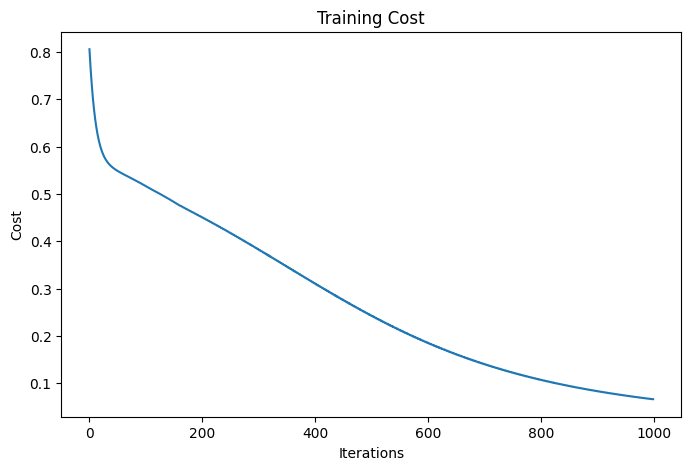

In [24]:


plt.figure(figsize=(8, 5))
plt.plot(costs)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Training Cost")
plt.show()

The training cost decreases throughout the optimization, indicating that the implemented forward propagation, cost function, backpropagation, and parameter updates work together to train the network.

# Gradient checking


Finally, we check if our gradients are correct. Since the gradients used in backpropagation were derived and implemented explicitly, it is useful to verify their correctness independently. This compares the analytical gradients obtained from backpropagation with numerical approximations computed using finite differences where the gradient is defined as:

$$
\frac{\partial J}{\partial \theta} \approx \frac{J( \theta + \epsilon ) - J(\theta - \epsilon)}{2 \epsilon}
$$

where $\theta$ can be a weight $W$ or a bias $b$ and $\epsilon$ an  small perturbation.  Agreement between the two provides a check that the derived gradients and their PyTorch implementation are consistent.

In [25]:
#X = X.double()
#Y = Y.double()

weights = {l: weights[l].double() for l in weights}
biases = {l: biases[l].double() for l in biases}

In [26]:
def cost_function(AL, Y):
    m = Y.shape[1]
    J = -torch.sum(
        Y * torch.log(AL) +
        (1 - Y) * torch.log(1 - AL)
    ) / m

    return J

In [27]:
def gradient_check(X, Y, weights, biases, epsilon=1e-5):

    L = len(weights)

    # Gradiente analítico
    AL, caches = forward_propagation(X, weights, biases)
    grad_J = backward_propagation(AL, Y, caches)

    for l in range(1, L + 1):

        print(f"\nLayer {l}")

        # ---- Check W ----
        W = weights[l]

        for i in range(W.shape[0]):
            for j in range(W.shape[1]):

                W_plus = W.clone()
                W_minus = W.clone()

                W_plus[i, j] += epsilon
                W_minus[i, j] -= epsilon

                weights_plus = weights.copy()
                weights_minus = weights.copy()

                weights_plus[l] = W_plus
                weights_minus[l] = W_minus

                AL_plus, _ = forward_propagation(
                    X, weights_plus, biases
                )

                AL_minus, _ = forward_propagation(
                    X, weights_minus, biases
                )

                J_plus = cost(AL_plus, Y)
                J_minus = cost(AL_minus, Y)

                numerical = (J_plus - J_minus) / (2 * epsilon)

                analytical = grad_J[l][1][i, j]

                difference = abs(numerical - analytical)

                print(
                    f"dW[{i},{j}]: "
                    f"analytical={analytical.item():.8f}, "
                    f"numerical={numerical.item():.8f}, "
                    f"diff={difference.item():.2e}"
                )

        # ---- Check b ----
        b = biases[l]

        for i in range(b.shape[0]):

            b_plus = b.clone()
            b_minus = b.clone()

            b_plus[i] += epsilon
            b_minus[i] -= epsilon

            biases_plus = biases.copy()
            biases_minus = biases.copy()

            biases_plus[l] = b_plus
            biases_minus[l] = b_minus

            AL_plus, _ = forward_propagation(
                X, weights, biases_plus
            )

            AL_minus, _ = forward_propagation(
                X, weights, biases_minus
            )

            J_plus = cost(AL_plus, Y)
            J_minus = cost(AL_minus, Y)

            numerical = (J_plus - J_minus) / (2 * epsilon)

            analytical = grad_J[l][2][i]

            difference = abs(numerical - analytical)

            print(
                f"db[{i}]: "
                f"analytical={analytical.item():.8f}, "
                f"numerical={numerical.item():.8f}, "
                f"diff={difference.item():.2e}"
            )

For gradient checking, all tensors are converted to double precision (float64) to reduce numerical errors in the finite-difference approximation of the gradients.

In [28]:
X = X.double()
Y = Y.double()

weights = {l: weights_test[l].double() for l in weights}
biases = {l: biases_test[l].double() for l in biases}
gradient_check(X, Y, weights, biases)


Layer 1
dW[0,0]: analytical=-0.06714932, numerical=-0.06714932, diff=3.62e-12
dW[0,1]: analytical=-0.11238216, numerical=-0.11238216, diff=4.43e-12
dW[0,2]: analytical=-0.06644194, numerical=-0.06644194, diff=9.86e-12
dW[1,0]: analytical=0.00000000, numerical=0.00000000, diff=0.00e+00
dW[1,1]: analytical=0.00000000, numerical=0.00000000, diff=0.00e+00
dW[1,2]: analytical=0.00000000, numerical=0.00000000, diff=0.00e+00
dW[2,0]: analytical=0.03002744, numerical=0.03002744, diff=3.66e-13
dW[2,1]: analytical=0.05300337, numerical=0.05300337, diff=1.24e-12
dW[2,2]: analytical=-0.00903223, numerical=-0.00903223, diff=2.47e-13
dW[3,0]: analytical=0.09824312, numerical=0.09824312, diff=3.89e-12
dW[3,1]: analytical=0.16442124, numerical=0.16442124, diff=8.32e-12
dW[3,2]: analytical=0.09720818, numerical=0.09720818, diff=1.12e-11
db[0]: analytical=-0.12404120, numerical=-0.12404120, diff=3.61e-12
db[1]: analytical=0.00000000, numerical=0.00000000, diff=0.00e+00
db[2]: analytical=0.03528372, num

 The difference between the analytical and numerical gradients is close to zero, confirming the correctness of the derived gradients and their implementation.


$$
\Biggl|\frac{\partial J}{\partial \theta}_{\text{analytical}} -
\frac{\partial J}{\partial \theta}_{\text{numerical}} \Biggr|
\approx 0
$$
